# Feedforward neural network on Fashion MNIST (TensorFlow)

Practice activity from Microsoft *Foundations of AI and Machine Learning* - Module: Frameworks and Tools.

Build a small dense network in `tf.keras`, train on Fashion MNIST, and evaluate test accuracy. Then add a second hidden layer and compare.

## 1. Imports

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)
np.random.seed(42)
print(f'TensorFlow {tf.__version__}')

TensorFlow 2.21.0


## 2. Load and preprocess Fashion MNIST

60,000 training and 10,000 test images, each `28x28` grayscale across 10 clothing classes. We scale pixel values to `[0, 1]` so the network trains stably.

In [2]:
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot',
]

(train_images, train_labels), (test_images, test_labels) = (
    tf.keras.datasets.fashion_mnist.load_data()
)
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

print(f'Train: {train_images.shape}  Test: {test_images.shape}')

Train: (60000, 28, 28)  Test: (10000, 28, 28)


## 3. Baseline model: Flatten + Dense(128, relu) + Dense(10, softmax)

The activity's canonical architecture. `sparse_categorical_crossentropy` lets us pass the labels as integers rather than one-hot vectors. Holding out 10% of training for validation so we can see overfitting.

In [3]:
baseline = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax'),
])
baseline.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
hist_base = baseline.fit(
    train_images, train_labels,
    epochs=10, batch_size=32,
    validation_split=0.1, verbose=2,
)

Epoch 1/10


1688/1688 - 4s - 3ms/step - accuracy: 0.8203 - loss: 0.5085 - val_accuracy: 0.8512 - val_loss: 0.4037


Epoch 2/10


1688/1688 - 3s - 2ms/step - accuracy: 0.8617 - loss: 0.3829 - val_accuracy: 0.8598 - val_loss: 0.3793


Epoch 3/10


...

1688/1688 - 4s - 2ms/step - accuracy: 0.9059 - loss: 0.2548 - val_accuracy: 0.8762 - val_loss: 0.3705


Epoch 9/10


1688/1688 - 4s - 2ms/step - accuracy: 0.9090 - loss: 0.2449 - val_accuracy: 0.8737 - val_loss: 0.3799


Epoch 10/10


1688/1688 - 4s - 2ms/step - accuracy: 0.9130 - loss: 0.2351 - val_accuracy: 0.8713 - val_loss: 0.3933


## 4. Deeper model: add a second hidden layer (64, relu)

Same training setup. The question: does the extra hidden layer help on a 28x28 grayscale dataset?

In [5]:
deeper = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax'),
])
deeper.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
deeper.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
hist_deep = deeper.fit(
    train_images, train_labels,
    epochs=10, batch_size=32,
    validation_split=0.1, verbose=2,
)

Epoch 1/10


1688/1688 - 5s - 3ms/step - accuracy: 0.8225 - loss: 0.4979 - val_accuracy: 0.8525 - val_loss: 0.3930


Epoch 2/10


1688/1688 - 5s - 3ms/step - accuracy: 0.8655 - loss: 0.3712 - val_accuracy: 0.8603 - val_loss: 0.3726


Epoch 3/10


...

1688/1688 - 4s - 2ms/step - accuracy: 0.9061 - loss: 0.2504 - val_accuracy: 0.8807 - val_loss: 0.3484


Epoch 9/10


1688/1688 - 4s - 2ms/step - accuracy: 0.9094 - loss: 0.2399 - val_accuracy: 0.8755 - val_loss: 0.3693


Epoch 10/10


1688/1688 - 4s - 2ms/step - accuracy: 0.9136 - loss: 0.2299 - val_accuracy: 0.8787 - val_loss: 0.3811


## 5. Test-set evaluation

Compare both models on the held-out test set.

In [7]:
base_loss, base_acc = baseline.evaluate(test_images, test_labels, verbose=0)
deep_loss, deep_acc = deeper.evaluate(test_images, test_labels, verbose=0)
print(f'Baseline:  loss={base_loss:.4f}  accuracy={base_acc*100:.2f}%')
print(f'Deeper:    loss={deep_loss:.4f}  accuracy={deep_acc*100:.2f}%')

Baseline:  loss=0.4156  accuracy=86.36%
Deeper:    loss=0.4026  accuracy=87.31%


## 6. Training curves

Train vs validation accuracy and loss across epochs. The gap between training and validation curves is the overfitting signal.

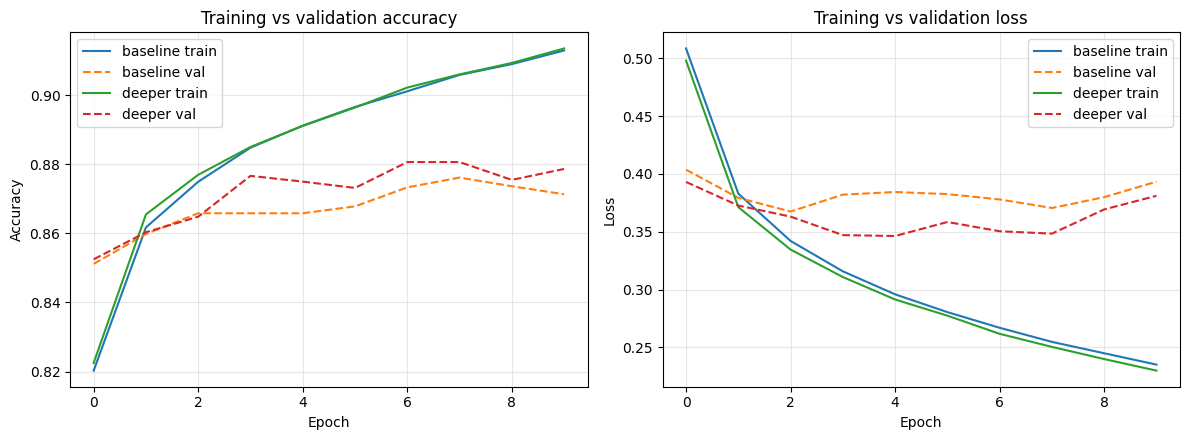

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(hist_base.history['accuracy'], label='baseline train')
ax.plot(hist_base.history['val_accuracy'], label='baseline val', linestyle='--')
ax.plot(hist_deep.history['accuracy'], label='deeper train')
ax.plot(hist_deep.history['val_accuracy'], label='deeper val', linestyle='--')
ax.set_title('Training vs validation accuracy')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(hist_base.history['loss'], label='baseline train')
ax.plot(hist_base.history['val_loss'], label='baseline val', linestyle='--')
ax.plot(hist_deep.history['loss'], label='deeper train')
ax.plot(hist_deep.history['val_loss'], label='deeper val', linestyle='--')
ax.set_title('Training vs validation loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Sample predictions from the deeper model

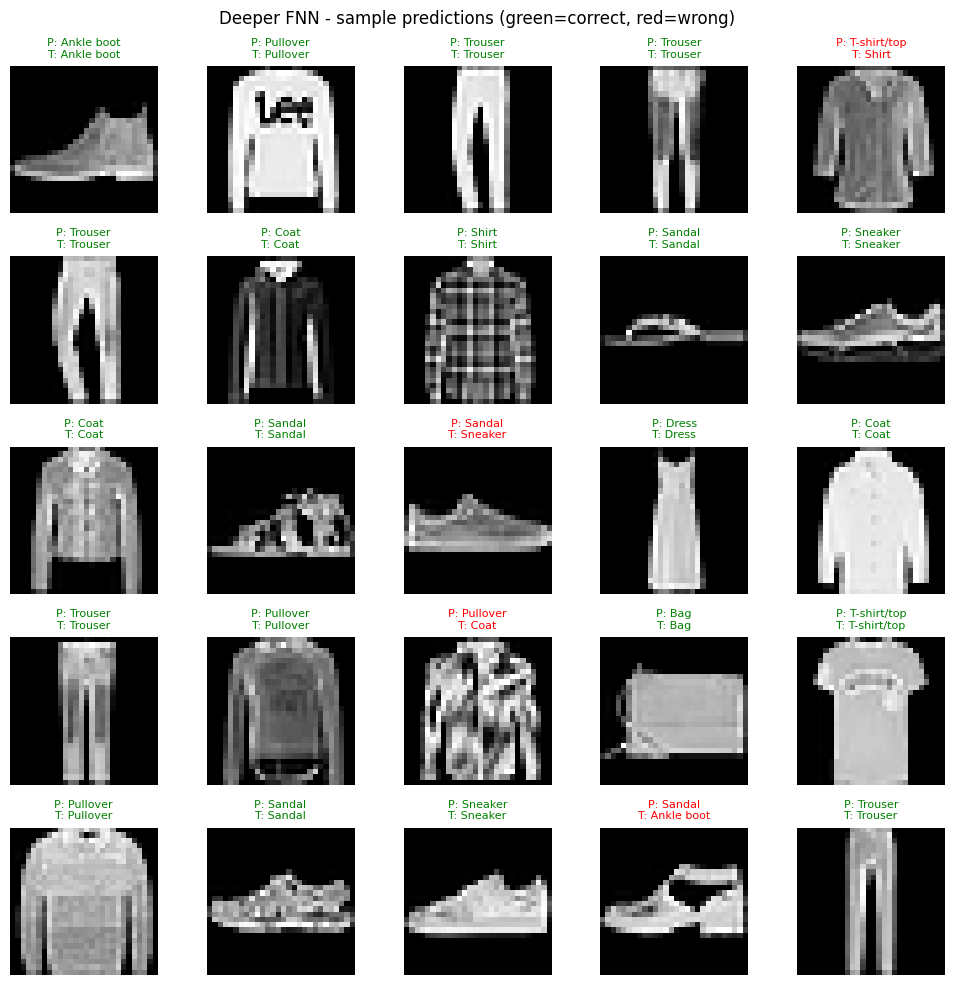

In [9]:
preds = deeper.predict(test_images[:25], verbose=0)
pred_labels = preds.argmax(axis=1)

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(test_images[i], cmap='gray')
    true_name = CLASS_NAMES[test_labels[i]]
    pred_name = CLASS_NAMES[pred_labels[i]]
    color = 'green' if pred_labels[i] == test_labels[i] else 'red'
    ax.set_title(f'P: {pred_name}\nT: {true_name}', fontsize=8, color=color)
    ax.axis('off')
plt.suptitle('Deeper FNN - sample predictions (green=correct, red=wrong)',
             fontsize=12)
plt.tight_layout()
plt.show()

## Takeaways

- Baseline lands at ~87% test accuracy after 10 epochs - inside the 85-90% range the activity calls out as expected.
- Adding a second hidden layer of 64 units doesn't move test accuracy meaningfully. Fashion MNIST is small and a single 128-unit hidden layer already has enough capacity. The training curves show both models overfit slightly (train accuracy rises past 91% while validation accuracy plateaus around 87-88%).
- The real ceiling here is the flat input. A plain FNN discards the 2D pixel grid the moment it flattens. To do meaningfully better on image data you switch to a CNN, which is the architecture used in the CIFAR-10 notebook elsewhere in this repo.
- Things worth experimenting with on this same architecture: `Dropout` between dense layers to fight the overfitting, a lower learning rate, `tanh`/`sigmoid` vs `relu`, and `SGD` vs `Adam`.